In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [5]:
ROOT = Path(r"C:\data_projects\market_research_customer_churn")
#ROOT = Path.cwd().parent
RAW_FILE = ROOT / "data" / "raw" / "telco_customer_churn.csv"
PROCESSED_DIR = ROOT / "data" / "processed"
CHART_DIR = ROOT / "Screenshots"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
CHART_DIR.mkdir(parents=True, exist_ok=True)

print("Raw file:", RAW_FILE)
print("Processed output:", PROCESSED_DIR)

Raw file: C:\data_projects\market_research_customer_churn\data\raw\telco_customer_churn.csv
Processed output: C:\data_projects\market_research_customer_churn\data\processed


In [6]:
df = pd.read_csv(RAW_FILE)

print("Dataset loaded successfully")
print("Shape:", df.shape)
display(df.head())

Dataset loaded successfully
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

print(df.columns.tolist())

['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents', 'tenure', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'monthlycharges', 'totalcharges', 'churn']


In [8]:
print("Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Customer IDs:")
if "customerid" in df.columns:
    print(df["customerid"].duplicated().sum())
elif "customer_id" in df.columns:
    print(df["customer_id"].duplicated().sum())

Shape: (7043, 21)

Data Types:
customerid              str
gender                  str
seniorcitizen         int64
partner                 str
dependents              str
tenure                int64
phoneservice            str
multiplelines           str
internetservice         str
onlinesecurity          str
onlinebackup            str
deviceprotection        str
techsupport             str
streamingtv             str
streamingmovies         str
contract                str
paperlessbilling        str
paymentmethod           str
monthlycharges      float64
totalcharges            str
churn                   str
dtype: object

Missing Values:
customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            

In [9]:
if "totalcharges" in df.columns:
    df["totalcharges"] = pd.to_numeric(df["totalcharges"], errors="coerce")

if "total_charges" in df.columns:
    df["total_charges"] = pd.to_numeric(df["total_charges"], errors="coerce")

In [10]:
rename_map = {
    "customerid": "customer_id",
    "totalcharges": "total_charges",
    "monthlycharges": "monthly_charges",
    "seniorcitizen": "senior_citizen",
    "phoneservice": "phone_service",
    "multiplelines": "multiple_lines",
    "internetservice": "internet_service",
    "onlinesecurity": "online_security",
    "onlinebackup": "online_backup",
    "deviceprotection": "device_protection",
    "techsupport": "tech_support",
    "streamingtv": "streaming_tv",
    "streamingmovies": "streaming_movies",
    "paperlessbilling": "paperless_billing",
    "paymentmethod": "payment_method"
}

df = df.rename(columns=rename_map)

print(df.columns.tolist())

['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents', 'tenure', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method', 'monthly_charges', 'total_charges', 'churn']


In [11]:
if "churn" in df.columns:
    df["churn_flag"] = df["churn"].map({"Yes": 1, "No": 0})
elif "churn_value" in df.columns:
    df["churn_flag"] = df["churn_value"]
else:
    raise ValueError("No churn column found. Please check dataset columns.")

df["churn_flag"] = df["churn_flag"].astype(int)

df[["churn_flag"]].head()

,churn_flag
0,0
1,0
2,1
3,0
4,1


In [12]:
service_columns = [
    "phone_service",
    "multiple_lines",
    "online_security",
    "online_backup",
    "device_protection",
    "tech_support",
    "streaming_tv",
    "streaming_movies"
]

available_service_columns = [col for col in service_columns if col in df.columns]

def service_active(value):
    if pd.isna(value):
        return 0
    value = str(value).lower()
    if value == "yes":
        return 1
    return 0

for col in available_service_columns:
    df[col + "_flag"] = df[col].apply(service_active)

service_flag_columns = [col + "_flag" for col in available_service_columns]

df["product_count"] = df[service_flag_columns].sum(axis=1)

display(df[["customer_id", "product_count"]].head())

,customer_id,product_count
0,7590-VHVEG,1
1,5575-GNVDE,3
2,3668-QPYBK,3
3,7795-CFOCW,3
4,9237-HQITU,1


In [13]:
def identify_need_gap(row):
    gaps = []

    if "online_security" in row.index and str(row["online_security"]).lower() != "yes":
        gaps.append("Security Need")

    if "tech_support" in row.index and str(row["tech_support"]).lower() != "yes":
        gaps.append("Support Need")

    if "online_backup" in row.index and str(row["online_backup"]).lower() != "yes":
        gaps.append("Backup Need")

    if "device_protection" in row.index and str(row["device_protection"]).lower() != "yes":
        gaps.append("Device Protection Need")

    if len(gaps) == 0:
        return "No Major Gap"

    return ", ".join(gaps)

df["customer_need_gap"] = df.apply(identify_need_gap, axis=1)

display(df[["customer_id", "customer_need_gap"]].head())

,customer_id,customer_need_gap
0,7590-VHVEG,"Security Need, Support Need, Device Protection..."
1,5575-GNVDE,"Support Need, Backup Need"
2,3668-QPYBK,"Support Need, Device Protection Need"
3,7795-CFOCW,Backup Need
4,9237-HQITU,"Security Need, Support Need, Backup Need, Devi..."


In [14]:
def product_change_recommendation(row):
    churn = row["churn_flag"]
    contract = str(row["contract"]).lower() if "contract" in row.index else ""
    tenure = row["tenure"] if "tenure" in row.index else 0
    monthly = row["monthly_charges"] if "monthly_charges" in row.index else 0
    product_count = row["product_count"]

    if churn == 1 and "month-to-month" in contract:
        return "Move to Long-Term Contract with Discount"

    elif churn == 1 and product_count <= 2:
        return "Bundle More Services with Retention Offer"

    elif churn == 0 and product_count >= 5:
        return "Upsell Premium Loyalty Package"

    elif churn == 0 and tenure >= 24 and monthly < 60:
        return "Cross-Sell Add-On Services"

    elif churn == 1 and monthly >= 80:
        return "Offer Price Optimization / Lower Plan"

    else:
        return "Maintain Current Plan"

df["product_change_recommendation"] = df.apply(product_change_recommendation, axis=1)

display(df[["customer_id", "churn_flag", "product_count", "product_change_recommendation"]].head())

,customer_id,churn_flag,product_count,product_change_recommendation
0,7590-VHVEG,0,1,Maintain Current Plan
1,5575-GNVDE,0,3,Cross-Sell Add-On Services
2,3668-QPYBK,1,3,Move to Long-Term Contract with Discount
3,7795-CFOCW,0,3,Cross-Sell Add-On Services
4,9237-HQITU,1,1,Move to Long-Term Contract with Discount


In [15]:
def churn_risk_category(row):
    if row["churn_flag"] == 1:
        return "Churned"

    tenure = row["tenure"] if "tenure" in row.index else 0
    contract = str(row["contract"]).lower() if "contract" in row.index else ""
    monthly = row["monthly_charges"] if "monthly_charges" in row.index else 0
    product_count = row["product_count"]

    if tenure <= 12 and "month-to-month" in contract and monthly >= 70:
        return "High Risk"

    elif tenure <= 24 and product_count <= 2:
        return "Medium Risk"

    else:
        return "Low Risk"

df["churn_risk_category"] = df.apply(churn_risk_category, axis=1)

display(df[["customer_id", "churn_flag", "churn_risk_category"]].head())

,customer_id,churn_flag,churn_risk_category
0,7590-VHVEG,0,Medium Risk
1,5575-GNVDE,0,Low Risk
2,3668-QPYBK,1,Churned
3,7795-CFOCW,0,Low Risk
4,9237-HQITU,1,Churned


In [16]:
segmentation_columns = []

for col in ["tenure", "monthly_charges", "total_charges", "product_count"]:
    if col in df.columns:
        segmentation_columns.append(col)

seg_df = df[segmentation_columns].copy()
seg_df = seg_df.fillna(seg_df.median(numeric_only=True))

scaler = StandardScaler()
scaled_data = scaler.fit_transform(seg_df)

silhouette_scores = {}

for k in range(2, 8):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(scaled_data)
    score = silhouette_score(scaled_data, labels)
    silhouette_scores[k] = score

silhouette_scores

{2: 0.46691416864110513,
 3: 0.4118787934119039,
 4: 0.41856464115733494,
 5: 0.38707523160519175,
 6: 0.37327313099740256,
 7: 0.36950297704939106}

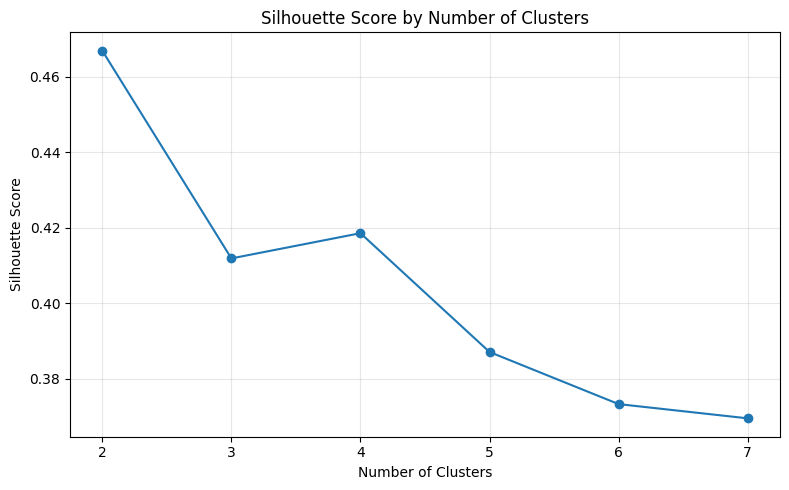

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker="o")
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CHART_DIR / "silhouette_score.png", dpi=150)
plt.show()

In [18]:
best_k = max(silhouette_scores, key=silhouette_scores.get)

print("Best number of clusters:", best_k)

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["customer_segment_id"] = kmeans.fit_predict(scaled_data)

Best number of clusters: 2


In [19]:
segment_profile = df.groupby("customer_segment_id").agg(
    customers=("customer_id", "count"),
    avg_tenure=("tenure", "mean"),
    avg_monthly_charges=("monthly_charges", "mean"),
    avg_total_charges=("total_charges", "mean"),
    avg_product_count=("product_count", "mean"),
    churn_rate=("churn_flag", "mean")
).reset_index()

segment_profile["churn_rate_pct"] = segment_profile["churn_rate"] * 100

display(segment_profile)

,customer_segment_id,customers,avg_tenure,avg_monthly_charges,avg_total_charges,avg_product_count,churn_rate,churn_rate_pct
0,0,4542,20.189784,50.728027,839.734694,2.176354,0.313959,31.395861
1,1,2501,54.493403,90.247861,4898.572891,5.517793,0.177129,17.712915


In [20]:
def assign_segment_name(row):
    if row["churn_rate_pct"] >= 40:
        return "High Churn Risk Customers"
    elif row["avg_product_count"] >= 5 and row["avg_monthly_charges"] >= 70:
        return "High Value Multi Product Customers"
    elif row["avg_tenure"] <= 12:
        return "New Low Loyalty Customers"
    elif row["avg_monthly_charges"] < 50:
        return "Price Sensitive Customers"
    else:
        return "Stable Core Customers"

segment_profile["segment_name"] = segment_profile.apply(assign_segment_name, axis=1)

df = df.merge(
    segment_profile[["customer_segment_id", "segment_name"]],
    on="customer_segment_id",
    how="left"
)

display(df[["customer_id", "customer_segment_id", "segment_name"]].head())

,customer_id,customer_segment_id,segment_name
0,7590-VHVEG,0,Stable Core Customers
1,5575-GNVDE,0,Stable Core Customers
2,3668-QPYBK,0,Stable Core Customers
3,7795-CFOCW,0,Stable Core Customers
4,9237-HQITU,0,Stable Core Customers


In [23]:
from pathlib import Path

PROCESSED_DIR = ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_FILE = PROCESSED_DIR / "customer_market_analysis_cleaned.csv"

df.to_csv(OUTPUT_FILE, index=False)

print("Processed file saved successfully")
print("Saved at:", OUTPUT_FILE)

Processed file saved successfully
Saved at: C:\data_projects\market_research_customer_churn\data\processed\customer_market_analysis_cleaned.csv


In [25]:
PROCESSED_DIR = ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# 1. Main cleaned dataset
df.to_csv(PROCESSED_DIR / "customer_market_analysis_cleaned.csv", index=False)

# 2. Churn summary
churn_summary = df.groupby("churn_flag").agg(
    customers=("customer_id", "count"),
    avg_monthly_charges=("monthly_charges", "mean"),
    avg_total_charges=("total_charges", "mean"),
    avg_product_count=("product_count", "mean")
).reset_index()

churn_summary["churn_status"] = churn_summary["churn_flag"].map({
    0: "Active",
    1: "Churned"
})

churn_summary.to_csv(PROCESSED_DIR / "churn_summary.csv", index=False)

# 3. Segment summary
segment_analysis = df.groupby("segment_name").agg(
    customers=("customer_id", "count"),
    churned=("churn_flag", "sum"),
    churn_rate=("churn_flag", "mean"),
    avg_tenure=("tenure", "mean"),
    avg_monthly_charges=("monthly_charges", "mean"),
    avg_total_charges=("total_charges", "mean"),
    avg_product_count=("product_count", "mean")
).reset_index()

segment_analysis["churn_rate_pct"] = segment_analysis["churn_rate"] * 100

segment_analysis.to_csv(PROCESSED_DIR / "segment_summary.csv", index=False)

# 4. Product need summary
product_need_analysis = df.groupby("customer_need_gap").agg(
    customers=("customer_id", "count"),
    churned=("churn_flag", "sum"),
    churn_rate=("churn_flag", "mean"),
    avg_monthly_charges=("monthly_charges", "mean")
).reset_index()

product_need_analysis["churn_rate_pct"] = product_need_analysis["churn_rate"] * 100

product_need_analysis.to_csv(PROCESSED_DIR / "product_need_summary.csv", index=False)

# 5. Product change summary
product_change_analysis = df.groupby("product_change_recommendation").agg(
    customers=("customer_id", "count"),
    churned=("churn_flag", "sum"),
    churn_rate=("churn_flag", "mean"),
    avg_monthly_charges=("monthly_charges", "mean"),
    avg_product_count=("product_count", "mean")
).reset_index()

product_change_analysis["churn_rate_pct"] = product_change_analysis["churn_rate"] * 100

product_change_analysis.to_csv(PROCESSED_DIR / "product_change_summary.csv", index=False)

print("All processed files saved successfully")
print("Saved inside:", PROCESSED_DIR)

All processed files saved successfully
Saved inside: C:\data_projects\market_research_customer_churn\data\processed
